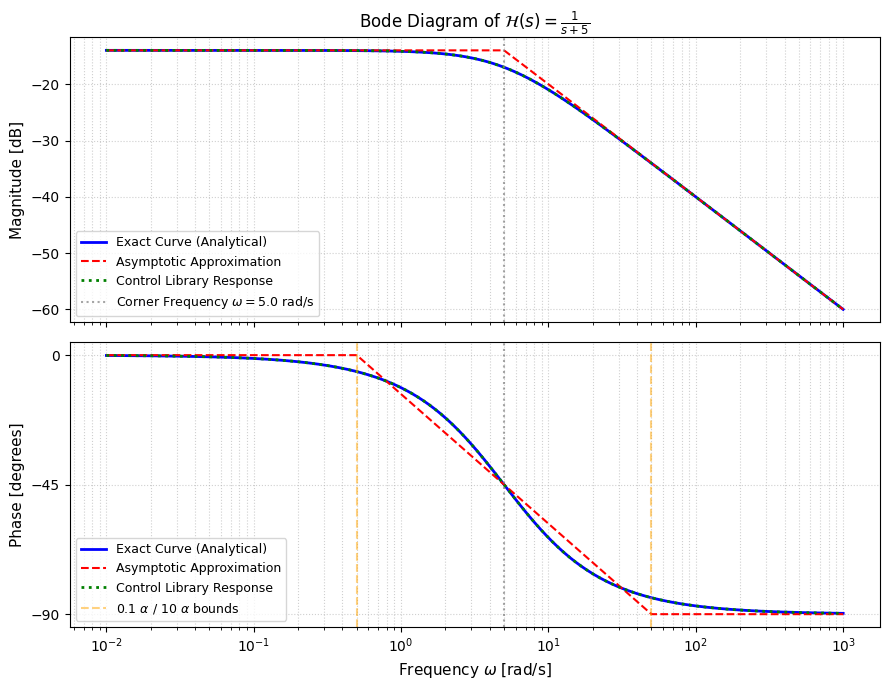

In [3]:
# Notebook: Bode Plot Construction for H(s) = 1 / (s + 5)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import control as ct

# 1. Define Transfer Function H(s) = 1 / (s + 5)
num_coeffs = [1.0]
den_coeffs = [1.0, 5.0]
H = ct.tf(num_coeffs, den_coeffs)

# 2. Frequency range spanning from 0.01 to 1000 rad/s (logarithmic scale)
omega = np.logspace(-2, 3, 500) # rad/s

# --- Analytical / Asymptotic Calculations (from your solution) ---
mag_const_db = 20 * np.log10(0.2) * np.ones_like(omega)
phase_const_deg = np.zeros_like(omega)

alpha = 5.0
mag_pole_exact_db = -10 * np.log10(1.0 + (omega / alpha)**2)
phase_pole_exact_deg = -np.rad2deg(np.arctan(omega / alpha))

mag_pole_asymp_db = np.zeros_like(omega)
mag_pole_asymp_db[omega >= alpha] = -20 * np.log10(omega[omega >= alpha] / alpha)

phase_pole_asymp_deg = np.zeros_like(omega)
phase_pole_asymp_deg[(omega >= 0.1 * alpha) & (omega <= 10 * alpha)] = -90.0 * (np.log10(omega[(omega >= 0.1 * alpha) & (omega <= 10 * alpha)]) - np.log10(0.1 * alpha)) / (np.log10(10 * alpha) - np.log10(0.1 * alpha))
phase_pole_asymp_deg[omega > 10 * alpha] = -90.0

# Superposition (Total Exact vs Total Asymptotic)
mag_total_exact_db = mag_const_db + mag_pole_exact_db
phase_total_exact_deg = phase_const_deg + phase_pole_exact_deg

mag_total_asymp_db = mag_const_db + mag_pole_asymp_db
phase_total_asymp_deg = phase_const_deg + phase_pole_asymp_deg

# 3. Using Python Control Library frequency response method (Warning-free)
response = H.frequency_response(omega)
mag_ct_db = 20 * np.log10(response.magnitude)
phase_ct_deg = np.rad2deg(response.phase)

# 4. Plotting using Matplotlib (Subplots for Magnitude and Phase)
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# --- Magnitude Plot ---
ax_mag.semilogx(omega, mag_total_exact_db, 'b-', linewidth=2, label='Exact Curve (Analytical)')
ax_mag.semilogx(omega, mag_total_asymp_db, 'r--', linewidth=1.5, label='Asymptotic Approximation')
ax_mag.semilogx(omega, mag_ct_db, 'g:', linewidth=2, label='Control Library Response')
ax_mag.axvline(alpha, color='gray', linestyle=':', alpha=0.7, label=f'Corner Frequency $\\omega = {alpha}$ rad/s')
ax_mag.set_ylabel('Magnitude [dB]', fontsize=11)
ax_mag.set_title(r'Bode Diagram of $\mathcal{H}(s) = \frac{1}{s+5}$', fontsize=12)
ax_mag.grid(True, which="both", linestyle=":", alpha=0.6)
ax_mag.legend(loc='lower left', fontsize=9, frameon=True)

# --- Phase Plot ---
ax_phase.semilogx(omega, phase_total_exact_deg, 'b-', linewidth=2, label='Exact Curve (Analytical)')
ax_phase.semilogx(omega, phase_total_asymp_deg, 'r--', linewidth=1.5, label='Asymptotic Approximation')
ax_phase.semilogx(omega, phase_ct_deg, 'g:', linewidth=2, label='Control Library Response')
ax_phase.axvline(alpha, color='gray', linestyle=':', alpha=0.7)
ax_phase.axvline(0.1 * alpha, color='orange', linestyle='--', alpha=0.5, label='0.1 $\\alpha$ / 10 $\\alpha$ bounds')
ax_phase.axvline(10 * alpha, color='orange', linestyle='--', alpha=0.5)
ax_phase.set_ylabel('Phase [degrees]', fontsize=11)
ax_phase.set_xlabel(r'Frequency $\omega$ [rad/s]', fontsize=11)
ax_phase.set_yticks([0, -45, -90])
ax_phase.grid(True, which="both", linestyle=":", alpha=0.6)
ax_phase.legend(loc='lower left', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()